==== Simulation summary ====
Volume shape in voxels: (50, 250, 250)
Voxel size: 1 mm
Physical slab size: (50.0, 250.0, 250.0) mm
Detector pitch: 4.375 mm
Detector effective diameter: 2 mm
Number of detectors: 1024
Time step: 55.00 ps
Total time window: 12.50 ns
Approx. number of time bins: 228
Optical properties: mua=0.0019, mus=1.4, g=0.9, n=1.4
nphoton: 1e+06
tstart: 0
tstep: 5.5e-11
tend: 1.25e-08
issrcfrom0: 1
autopilot: 1
unitinmm: 1
issavedet: 1
Result type: <class 'dict'>
Result keys: ['detp', 'flux', 'stat']


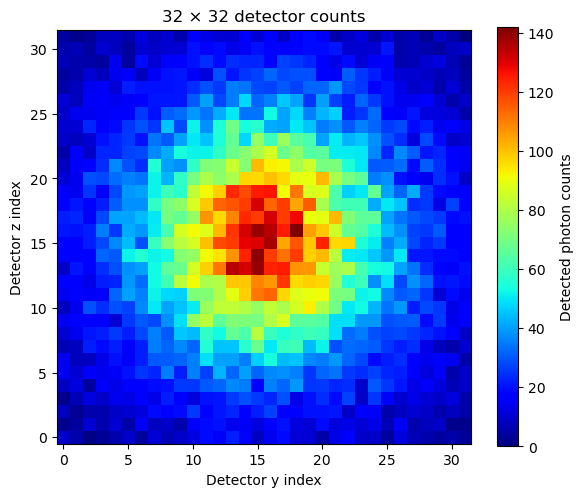

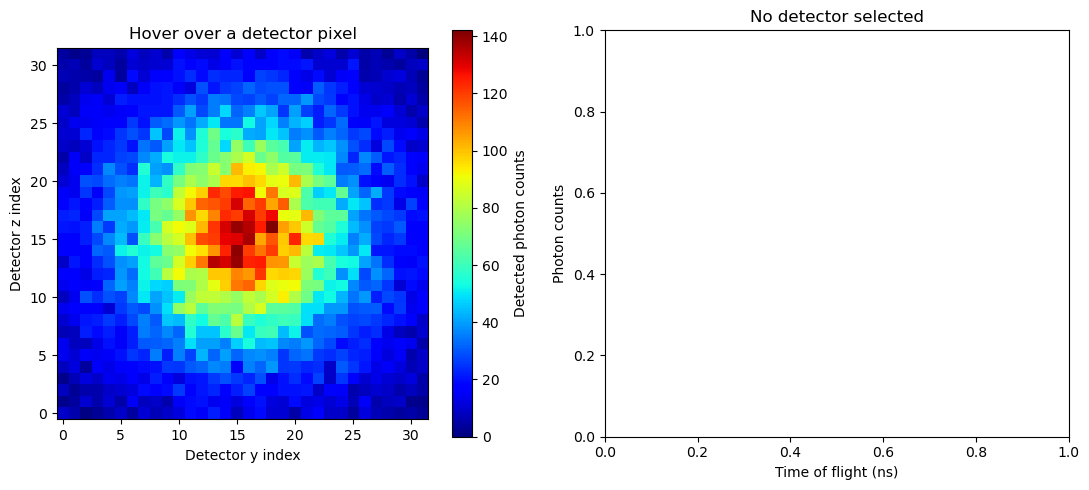

In [1]:
"""
pmcx simulation for a 250 x 250 x 50 mm foam slab
with a 32 x 32 detector array on the output surface.

Geometry convention:
    x axis: slab thickness direction, 0 -> 50 mm
    y axis: lateral width, 0 -> 250 mm
    z axis: lateral height, 0 -> 250 mm

Laser:
    injected from x = 0 surface
    direction: +x

Detector array:
    placed on x = 50 mm surface
    covers a 140 x 140 mm field of view
    32 x 32 detectors
    pitch = 140 / 32 = 4.375 mm

Time:
    time bin = 55 ps
    total window = 12.5 ns
"""

import numpy as np
import pmcx
import matplotlib.pyplot as plt


def build_detector_array_32x32(
    slab_thickness_mm=50.0,
    slab_width_mm=250.0,
    slab_height_mm=250.0,
    fov_mm=140.0,
    num_pix=32,
    detector_diameter_mm=1,
    voxel_size_mm=1.0,
    put_on_boundary=True,
):
    """
    Build 32 x 32 detector positions for MCX/pmcx.

    MCX positions are in voxel units, not directly in mm.
    Therefore all physical coordinates are divided by voxel_size_mm.

    Returns
    -------
    detpos : ndarray, shape (1024, 4)
        Each row is [x, y, z, radius] in voxel units.
    yy_mm : ndarray, shape (32,)
        Detector center y positions in mm.
    zz_mm : ndarray, shape (32,)
        Detector center z positions in mm.
    """

    pitch_mm = fov_mm / num_pix

    # Detector centers cover the central 140 x 140 mm area.
    # Use pixel-center convention:
    # offsets = -70 + pitch/2, ..., +70 - pitch/2
    offsets_mm = (np.arange(num_pix) + 0.5) * pitch_mm - fov_mm / 2

    y_center_mm = slab_width_mm / 2
    z_center_mm = slab_height_mm / 2

    yy_mm = y_center_mm + offsets_mm
    zz_mm = z_center_mm + offsets_mm

    if put_on_boundary:
        x_det_mm = slab_thickness_mm
    else:
        # Put detectors slightly inside the output surface.
        # This can sometimes be numerically more stable.
        x_det_mm = slab_thickness_mm - voxel_size_mm

    det_radius_mm = detector_diameter_mm / 2

    detpos = []
    for z_mm in zz_mm:
        for y_mm in yy_mm:
            detpos.append(
                [
                    x_det_mm / voxel_size_mm,
                    y_mm / voxel_size_mm,
                    z_mm / voxel_size_mm,
                    det_radius_mm / voxel_size_mm,
                ]
            )

    return np.asarray(detpos, dtype=np.float32), yy_mm, zz_mm


def make_foam_slab_cfg(
    nphoton=1_000_000,
    voxel_size_mm=1,
    slab_thickness_mm=50.0,
    slab_width_mm=250.0,
    slab_height_mm=250.0,
    mua=0.0019,
    mus=1.4,
    g=0.9,
    n=1.4,
    fov_mm=140.0,
    num_pix=32,
    detector_diameter_mm=0.61,
    tstep_ps=55.0,
    total_time_ns=12.5,
    gpuid=1,
    seed=123456789,
):
    """
    Construct pmcx configuration dictionary.

    Optical property convention for MCX:
        prop row = [mua, mus, g, n]

    Important:
        If your 1.4 value is actually reduced scattering coefficient mus',
        then you should set:
            mus = mus_prime / (1 - g)
        instead of directly using mus = 1.4.
    """

    # Convert physical dimensions to voxel counts.
    nx = int(round(slab_thickness_mm / voxel_size_mm))
    ny = int(round(slab_width_mm / voxel_size_mm))
    nz = int(round(slab_height_mm / voxel_size_mm))

    # Homogeneous volume: label 1 everywhere.
    # Shape convention: x, y, z.
    vol = np.ones((nx, ny, nz), dtype=np.uint8)

    # Source at the center of the left x = 0 surface.
    srcpos = [
        0.0,
        (slab_width_mm / 2) / voxel_size_mm,
        (slab_height_mm / 2) / voxel_size_mm,
    ]

    srcdir = [1.0, 0.0, 0.0]

    detpos, yy_mm, zz_mm = build_detector_array_32x32(
        slab_thickness_mm=slab_thickness_mm,
        slab_width_mm=slab_width_mm,
        slab_height_mm=slab_height_mm,
        fov_mm=fov_mm,
        num_pix=num_pix,
        detector_diameter_mm=detector_diameter_mm,
        voxel_size_mm=voxel_size_mm,
        put_on_boundary=True,
    )

    tstart = 0.0
    tend = total_time_ns * 1e-9
    tstep = tstep_ps * 1e-12

    cfg = {
        "nphoton": int(nphoton),
        "vol": vol,
        "unitinmm": voxel_size_mm,
        # Use a 0-based physical coordinate system: the slab spans
        # x/y/z = 0..size_mm, matching srcpos and detpos below.
        "issrcfrom0": 1,

        # Medium 0 is outside/background.
        # Medium 1 is foam.
        "prop": [
            [0.0, 0.0, 1.0, 1.0],
            [mua, mus, g, n],
        ],

        "srcpos": srcpos,
        "srcdir": srcdir,
        "srctype": "pencil",

        "detpos": detpos,

        "tstart": tstart,
        "tend": tend,
        "tstep": tstep,

        "seed": seed,
        "gpuid": gpuid,
        "autopilot": 1,

        # Save detected photon information.
        # d: detector ID
        # p: partial path length
        # x/v/w flags may vary by MCX version; keep this conservative.
        "issavedet": 1,
        "savedetflag": "dp",

        # Output fluence/flux field as time gates.
        # This can be memory-heavy for large grids and many time bins.
        "outputtype": "flux",

        # Boundary condition:
        # keep default unless you specifically want reflection/refraction behavior changed.
        # You can later add cfg["bc"] if needed.
        "debuglevel": "P",
    }

    meta = {
        "voxel_size_mm": voxel_size_mm,
        "volume_shape_voxels": (nx, ny, nz),
        "slab_size_mm": (slab_thickness_mm, slab_width_mm, slab_height_mm),
        "srcpos_vox": srcpos,
        "srcpos_mm": [0.0, slab_width_mm / 2, slab_height_mm / 2],
        "srcdir": srcdir,
        "detpos_vox": detpos,
        "detector_y_mm": yy_mm,
        "detector_z_mm": zz_mm,
        "detector_pitch_mm": fov_mm / num_pix,
        "detector_diameter_mm": detector_diameter_mm,
        "fov_mm": fov_mm,
        "num_pix": num_pix,
        "tstart_s": tstart,
        "tend_s": tend,
        "tstep_s": tstep,
        "num_time_bins_approx": int(np.ceil((tend - tstart) / tstep)),
        "mua_mm_inv": mua,
        "mus_mm_inv": mus,
        "g": g,
        "n": n,
        "issrcfrom0": 1,

    }

    return cfg, meta


def run_foam_slab_simulation(
    nphoton=10_000_000,
    voxel_size_mm=0.5,
    detector_diameter_mm=0.61,
    mua=0.0019,
    mus=1.4,
    g=0.9,
    n=1.4,
    gpuid=1,
):
    """
    Run pmcx simulation and return raw result, config, and metadata.
    """

    cfg, meta = make_foam_slab_cfg(
        nphoton=nphoton,
        voxel_size_mm=voxel_size_mm,
        detector_diameter_mm=detector_diameter_mm,
        mua=mua,
        mus=mus,
        g=g,
        n=n,
        gpuid=gpuid,
    )

    print("==== Simulation summary ====")
    print(f"Volume shape in voxels: {meta['volume_shape_voxels']}")
    print(f"Voxel size: {meta['voxel_size_mm']} mm")
    print(f"Physical slab size: {meta['slab_size_mm']} mm")
    print(f"Detector pitch: {meta['detector_pitch_mm']} mm")
    print(f"Detector effective diameter: {meta['detector_diameter_mm']} mm")
    print(f"Number of detectors: {cfg['detpos'].shape[0]}")
    print(f"Time step: {meta['tstep_s'] * 1e12:.2f} ps")
    print(f"Total time window: {meta['tend_s'] * 1e9:.2f} ns")
    print(f"Approx. number of time bins: {meta['num_time_bins_approx']}")
    print(f"Optical properties: mua={mua}, mus={mus}, g={g}, n={n}")
    det_radius_vox = (detector_diameter_mm / 2) / voxel_size_mm
    if det_radius_vox < 0.25:
        print(
            "WARNING: detector radius is much smaller than one voxel "
            f"({det_radius_vox:.3f} vox). MCX may detect zero photons. "
            "Use a finer voxel size or a larger effective detector diameter."
        )
    print("============================")

    # Official pmcx examples recommend mcxlab-style dict execution.
    res = pmcx.mcxlab(cfg)

    return res, cfg, meta


def extract_detector_id_from_detp(detp):
    """
    Try to extract detector ID from pmcx detected photon output.

    Different pmcx versions may return detp in slightly different structures.
    This helper is intentionally defensive.
    """

    if detp is None:
        return None

    if isinstance(detp, dict):
        for key in ["detid", "det", "detid_data", "d"]:
            if key in detp:
                return np.asarray(detp[key]).astype(int)

    if isinstance(detp, np.ndarray):
        # Often first column is DetID if savedetflag includes d.
        if detp.ndim == 2 and detp.shape[1] >= 1:
            return detp[:, 0].astype(int)

    return None


def extract_partial_path_from_detp(detp):
    """
    Try to extract detected-photon partial path lengths from pmcx output.

    Returns
    -------
    ppath : ndarray, shape (num_detected, num_media)
        Partial path lengths in voxel units. Multiply by cfg["unitinmm"] to
        convert to mm.
    """

    if detp is None:
        return None

    if isinstance(detp, dict):
        for key in ["ppath", "p"]:
            if key in detp:
                ppath = np.asarray(detp[key], dtype=float)
                if ppath.ndim == 1:
                    ppath = ppath[:, None]
                return ppath

        # pmcx stores a concatenated array in detp["data"]. With savedetflag
        # "dp", row 0 is detid and remaining row(s) are partial path lengths.
        if "data" in detp:
            data = np.asarray(detp["data"], dtype=float)
            if data.ndim == 2 and data.shape[0] >= 2:
                return data[1:, :].T

    if isinstance(detp, np.ndarray):
        if detp.ndim == 2 and detp.shape[1] >= 2:
            return detp[:, 1:]

    return None


def detector_id_to_zero_based(detid, num_detectors):
    """
    Convert MCX/pmcx detector IDs to zero-based detector indices.
    """

    detid = np.asarray(detid).astype(int)
    if detid.size == 0:
        return detid

    # MCX detector ID is 1-based in pmcx 0.6/0.7. The minimum ID may be larger
    # than 1 if no photons hit detector 1, so check the maximum as well.
    if detid.min() >= 1 and detid.max() <= num_detectors:
        return detid - 1

    return detid


def quick_plot_detector_counts(res, num_pix=32):
    """
    Plot the number of detected photons per detector as a 32 x 32 image.

    This relies on saved detector IDs. If the current pmcx version returns
    detector data under a different field name, print the result keys first.
    """

    print("Result type:", type(res))

    if isinstance(res, dict):
        print("Result keys:", list(res.keys()))

    detp = None
    if isinstance(res, dict):
        for key in ["detp", "detphoton", "detphotons"]:
            if key in res:
                detp = res[key]
                break

    detid = extract_detector_id_from_detp(detp)

    if detid is None:
        print("Could not find detector IDs in result.")
        print("Check the pmcx result structure above.")
        return None

    detid0 = detector_id_to_zero_based(detid, num_pix * num_pix)

    valid = (detid0 >= 0) & (detid0 < num_pix * num_pix)
    if not np.all(valid):
        print(f"Ignoring {np.count_nonzero(~valid)} detector IDs outside 0..{num_pix * num_pix - 1}.")
        detid0 = detid0[valid]

    counts = np.bincount(detid0, minlength=num_pix * num_pix)
    img = counts.reshape(num_pix, num_pix)

    plt.figure(figsize=(6, 5))
    plt.imshow(img, origin="lower",cmap="jet")
    plt.colorbar(label="Detected photon counts")
    plt.title("32 × 32 detector counts")
    plt.xlabel("Detector y index")
    plt.ylabel("Detector z index")
    plt.tight_layout()
    plt.show()

    return img


def interactive_detector_histogram(
    res,
    cfg=None,
    num_pix=32,
    bins=80,
    min_count_to_plot=1,
):
    """
    Show detector counts and update a per-pixel photon time curve on hover.

    Parameters
    ----------
    res : dict
        pmcx.mcxlab result containing res["detp"].
    cfg : dict, optional
        Simulation config. Used for unitinmm and refractive indices when
        hist_mode="time_ns".
    num_pix : int
        Detector array width/height. Default is 32 for a 32 x 32 array.
    bins : int
        Number of time bins used to estimate the displayed photon curve.
    min_count_to_plot : int
        Only update the histogram when the hovered detector has at least this
        many photons.

    Returns
    -------
    fig, axes, state
        Matplotlib figure, axes, and a small state dict holding the callback id
        and precomputed arrays.
    """

    if not isinstance(res, dict):
        raise TypeError("res must be the dictionary returned by pmcx.mcxlab")

    detp = None
    for key in ["detp", "detphoton", "detphotons"]:
        if key in res:
            detp = res[key]
            break

    detid = extract_detector_id_from_detp(detp)
    ppath = extract_partial_path_from_detp(detp)

    if detid is None:
        raise ValueError("Could not find detector IDs in pmcx result.")
    if ppath is None:
        raise ValueError('Could not find partial path lengths. Use savedetflag="dp".')

    num_detectors = num_pix * num_pix
    detid0 = detector_id_to_zero_based(detid, num_detectors)
    valid = (detid0 >= 0) & (detid0 < num_detectors)
    detid0 = detid0[valid]
    ppath = ppath[valid]

    counts = np.bincount(detid0, minlength=num_detectors)
    count_img = counts.reshape(num_pix, num_pix)

    unitinmm = 1.0
    if cfg is not None:
        unitinmm = float(cfg.get("unitinmm", unitinmm))

    path_mm = np.sum(ppath, axis=1) * unitinmm

    c_mm_per_ns = 299.792458
    refractive_indices = None
    if cfg is not None and "prop" in cfg:
        prop = np.asarray(cfg["prop"], dtype=float)
        if prop.ndim == 2 and prop.shape[1] >= 4:
            # ppath columns correspond to non-background media.
            refractive_indices = prop[1 : 1 + ppath.shape[1], 3]

    if refractive_indices is not None and refractive_indices.size == ppath.shape[1]:
        photon_time_ns = np.sum(ppath * unitinmm * refractive_indices[None, :], axis=1) / c_mm_per_ns
    else:
        n_eff = 1.0
        if cfg is not None and "prop" in cfg:
            prop = np.asarray(cfg["prop"], dtype=float)
            if prop.ndim == 2 and prop.shape[0] > 1 and prop.shape[1] >= 4:
                n_eff = float(prop[1, 3])
        photon_time_ns = path_mm * n_eff / c_mm_per_ns

    xlabel = "Time of flight (ns)"

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    ax_img, ax_hist = axes

    im = ax_img.imshow(count_img, origin="lower", cmap="jet")
    fig.colorbar(im, ax=ax_img, label="Detected photon counts")
    ax_img.set_title("Hover over a detector pixel")
    ax_img.set_xlabel("Detector y index")
    ax_img.set_ylabel("Detector z index")

    ax_hist.set_title("No detector selected")
    ax_hist.set_xlabel(xlabel)
    ax_hist.set_ylabel("Photon counts")

    highlight = ax_img.scatter([], [], s=80, facecolors="none", edgecolors="white", linewidths=1.5)
    last_det = {"id": None}

    def update_hist(event):
        if event.inaxes is not ax_img or event.xdata is None or event.ydata is None:
            return

        y_idx = int(np.floor(event.xdata + 0.5))
        z_idx = int(np.floor(event.ydata + 0.5))

        if y_idx < 0 or y_idx >= num_pix or z_idx < 0 or z_idx >= num_pix:
            return

        det_index = z_idx * num_pix + y_idx
        if det_index == last_det["id"]:
            return

        last_det["id"] = det_index
        photon_values = photon_time_ns[detid0 == det_index]

        ax_hist.clear()
        ax_hist.set_xlabel(xlabel)
        ax_hist.set_ylabel("Photon counts")

        count = photon_values.size
        if count >= min_count_to_plot:
            hist, edges = np.histogram(photon_values, bins=bins)
            centers = 0.5 * (edges[:-1] + edges[1:])
            ax_hist.plot(centers, hist, lw=1.8)
            ax_hist.set_ylim(bottom=0)
            ax_hist.set_title(f"Pixel y={y_idx}, z={z_idx}, photons={count}")
        else:
            ax_hist.set_title(f"Pixel y={y_idx}, z={z_idx}, photons={count}")
            ax_hist.text(0.5, 0.5, "No photons", ha="center", va="center", transform=ax_hist.transAxes)

        highlight.set_offsets([[y_idx, z_idx]])
        fig.canvas.draw_idle()

    callback_id = fig.canvas.mpl_connect("motion_notify_event", update_hist)
    fig.tight_layout()
    plt.show()

    state = {
        "callback_id": callback_id,
        "detid0": detid0,
        "photon_time_ns": photon_time_ns,
        "count_img": count_img,
    }
    return fig, axes, state


if __name__ == "__main__":
    # Start with fewer photons for debugging.
    # After confirming geometry and detected counts, increase to 1e8 or higher.
    res, cfg, meta = run_foam_slab_simulation(
        nphoton= 1_000_000,
        voxel_size_mm=1,
        detector_diameter_mm=2,
        mua=0.0019,
        mus=1.4,
        g=0.9,
        n=1.4,
        gpuid=1,
    )

    det_img = quick_plot_detector_counts(res, num_pix=32)

    interactive_detector_histogram(
    res,
    cfg=cfg,
    num_pix=32,
    bins=80,
    )

    # Save useful outputs.
    np.savez(
        "foam_slab_32x32_pmcx_result_meta.npz",
        detpos_vox=meta["detpos_vox"],
        detector_y_mm=meta["detector_y_mm"],
        detector_z_mm=meta["detector_z_mm"],
        detector_pitch_mm=meta["detector_pitch_mm"],
        detector_diameter_mm=meta["detector_diameter_mm"],
        voxel_size_mm=meta["voxel_size_mm"],
        slab_size_mm=np.asarray(meta["slab_size_mm"]),
        tstart_s=meta["tstart_s"],
        tend_s=meta["tend_s"],
        tstep_s=meta["tstep_s"],
        mua_mm_inv=meta["mua_mm_inv"],
        mus_mm_inv=meta["mus_mm_inv"],
        g=meta["g"],
        n=meta["n"],
    )

    if det_img is not None:
        np.save("foam_slab_32x32_detector_counts.npy", det_img)
